   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


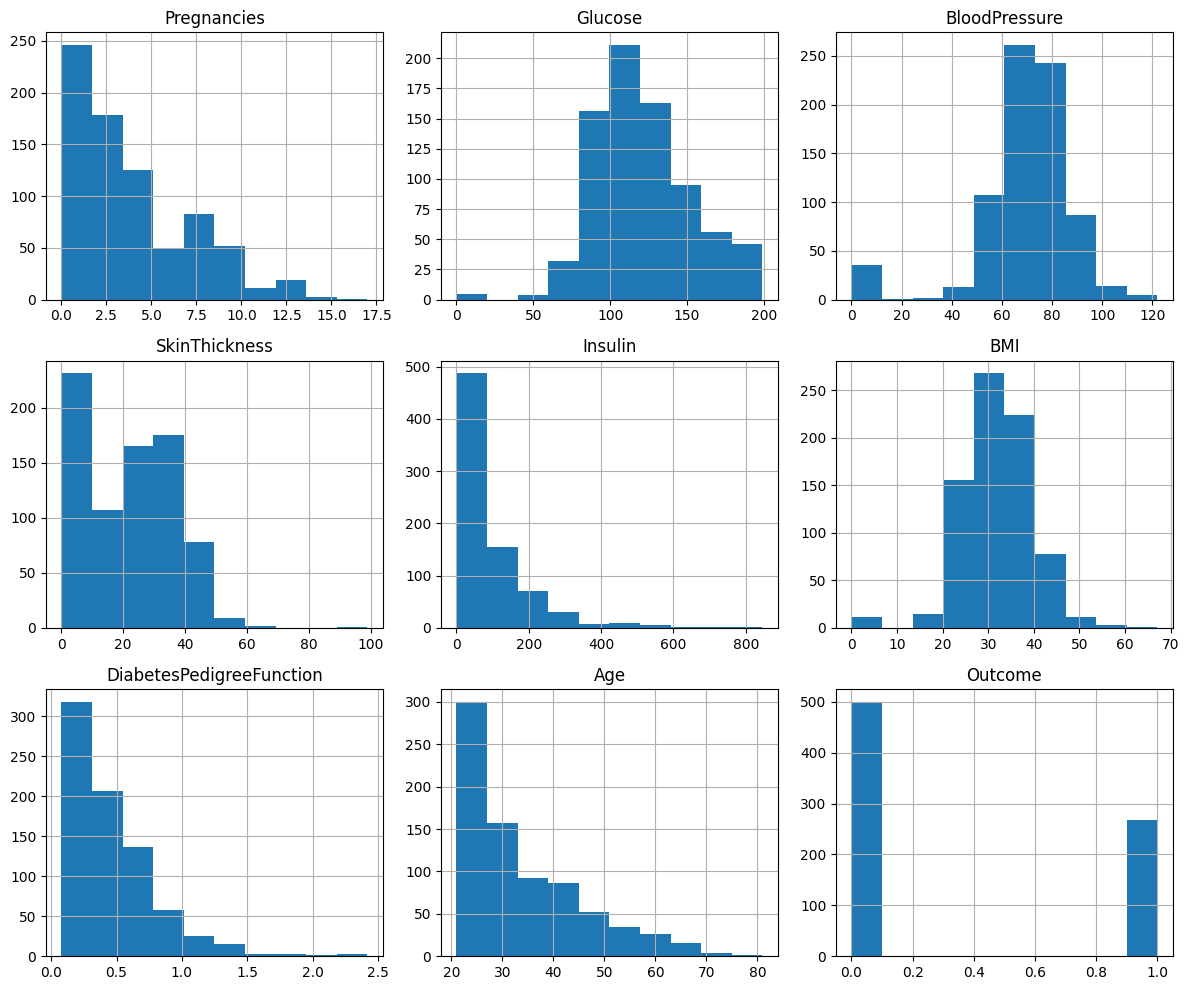

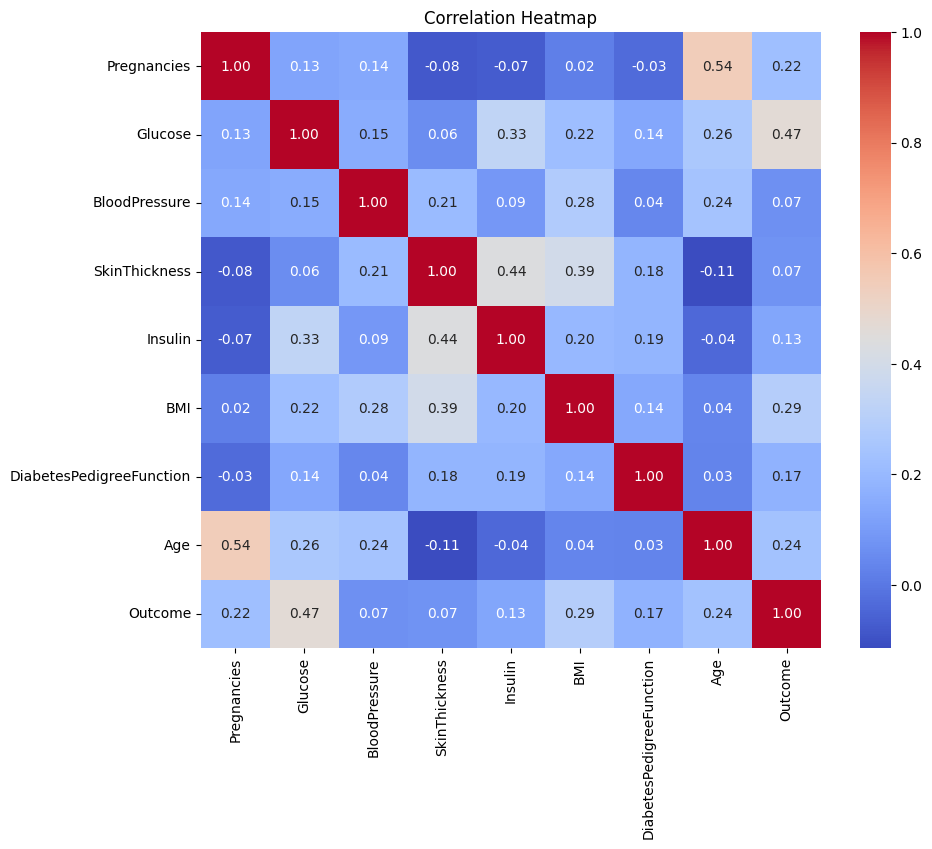

Accuracy: 0.7532467532467533
Confusion Matrix:
[[79 20]
 [18 37]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = pd.read_csv("/content/diabetes.csv")

print(data.head())

data.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

numeric_data = data.select_dtypes(include=["int64", "float64"])

correlation = numeric_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

x = data.drop("Outcome", axis=1)
y = data["Outcome"]

x_train, x_test, y_train, y_test = train_test_split(
x,
y,
test_size=0.2,
random_state=42
)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

predictions = model.predict(x_test)

accuracy = accuracy_score(y_test, predictions)

matrix = confusion_matrix(y_test, predictions)
report = classification_report(y_test, predictions)

print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(matrix)
print("Classification Report:")
print(report)
